In [1]:
cd /content/drive/MyDrive/cv_22641171_NgoTruongDinh/lab_bo_sung_10 03 2026

/content/drive/MyDrive/cv_22641171_NgoTruongDinh/lab_bo_sung_10 03 2026


In [2]:
!cp -r '/content/drive/MyDrive/cv_22641171_NgoTruongDinh/lab_bo_sung_10 03 2026/new_Data/mine_new_dataset_encrypted/new_dataset_encrypted' /content

In [3]:
!cp -r '/content/drive/MyDrive/cv_22641171_NgoTruongDinh/lab_bo_sung_10 03 2026/new_Data/new_dataset_processed' /content

In [4]:
import numpy as np
from PIL import Image
from pathlib import Path
from tqdm.auto import tqdm
from multiprocessing import Pool, cpu_count
from sklearn.model_selection import train_test_split

DATA_DIR = "/content/new_dataset_processed"
DATA_ENC = "/content/new_dataset_encrypted"

SEED = 42
TEST_SIZE = 0.15
VAL_SIZE = 0.15


def process_image(path):
    img = np.array(Image.open(path).convert("L"), dtype=np.float32) / 255.0
    s = img.sum()
    s2 = (img ** 2).sum()
    n = img.size
    return s, s2, n


def mean_std_fast(image_paths):
    total_sum = 0.0
    total_sq = 0.0
    total_pixels = 0

    with Pool(cpu_count()) as pool:
        for s, s2, n in tqdm(
            pool.imap_unordered(process_image, image_paths, chunksize=32),
            total=len(image_paths)
        ):
            total_sum += s
            total_sq += s2
            total_pixels += n

    mean = total_sum / total_pixels
    std = np.sqrt(total_sq / total_pixels - mean ** 2)

    return mean, std


def get_paths_and_labels(data_dir):
    paths = list(Path(data_dir).rglob("*.png"))

    # label = tên folder cha
    labels = [p.parent.name for p in paths]

    return paths, labels


def split_dataset(data_dir):
    paths, labels = get_paths_and_labels(data_dir)

    train_paths, temp_paths, train_labels, temp_labels = train_test_split(
        paths,
        labels,
        test_size=TEST_SIZE + VAL_SIZE,
        random_state=SEED,
        stratify=labels
    )

    val_ratio = VAL_SIZE / (TEST_SIZE + VAL_SIZE)

    val_paths, test_paths, val_labels, test_labels = train_test_split(
        temp_paths,
        temp_labels,
        test_size=1 - val_ratio,
        random_state=SEED,
        stratify=temp_labels
    )

    return train_paths, val_paths, test_paths


print("Data original")
train_paths, val_paths, test_paths = split_dataset(DATA_DIR)

print("Train:", len(train_paths))
print("Val:", len(val_paths))
print("Test:", len(test_paths))

mean, std = mean_std_fast(train_paths)
print("Train mean:", mean)
print("Train std:", std)


print("\nData encrypted")
train_paths_enc, val_paths_enc, test_paths_enc = split_dataset(DATA_ENC)

print("Train:", len(train_paths_enc))
print("Val:", len(val_paths_enc))
print("Test:", len(test_paths_enc))

mean_enc, std_enc = mean_std_fast(train_paths_enc)
print("Encrypted train mean:", mean_enc)
print("Encrypted train std:", std_enc)

Data original
Train: 3659
Val: 784
Test: 785


  0%|          | 0/3659 [00:00<?, ?it/s]

Train mean: 0.5008547
Train std: 0.24023934

Data encrypted
Train: 3659
Val: 784
Test: 785


  0%|          | 0/3659 [00:00<?, ?it/s]

Encrypted train mean: 0.12642418
Encrypted train std: 0.18935998


In [5]:
!pip install -q open_clip_torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 83.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 5.1 MB/s eta 0:00:00


In [6]:
from foundation_model import ModelLoader

loader = ModelLoader()

# load models
clip_model, clip_preprocess = loader.load_clip()
dino_model, dino_preprocess = loader.load_dino()
resnet_model, resnet_preprocess = loader.load_resnet()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


Downloading: "https://github.com/facebookresearch/dino/zipball/main" to /root/.cache/torch/hub/main.zip
Downloading: "https://dl.fbaipublicfiles.com/dino/dino_vitbase16_pretrain/dino_vitbase16_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dino_vitbase16_pretrain.pth


100%|██████████| 327M/327M [00:00<00:00, 516MB/s]


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 238MB/s]


In [7]:
from torch.utils.data import DataLoader, Dataset
from pathlib import Path
from PIL import Image

NUM_WORKERS = 12
BATCH_SIZE = 200


class ImageDataset(Dataset):
    def __init__(self, paths, transform):
        self.paths = paths
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        p = self.paths[idx]

        img = Image.open(p).convert("RGB")
        img = self.transform(img)

        label = p.parent.name
        return img, label


# dùng lại data đã chia từ bước trước
# train_paths, val_paths, test_paths
# train_paths_enc, val_paths_enc, test_paths_enc


# =========================
# ORIGIN - TRAIN
# =========================
clip_dataset_origin = ImageDataset(train_paths, clip_preprocess)
dino_dataset_origin = ImageDataset(train_paths, dino_preprocess)
resnet_dataset_origin = ImageDataset(train_paths, resnet_preprocess)

clip_loader_origin = DataLoader(
    clip_dataset_origin,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

dino_loader_origin = DataLoader(
    dino_dataset_origin,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

resnet_loader_origin = DataLoader(
    resnet_dataset_origin,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)


# =========================
# ENCRYPTED - TRAIN
# =========================
clip_dataset_encrypted = ImageDataset(train_paths_enc, clip_preprocess)
dino_dataset_encrypted = ImageDataset(train_paths_enc, dino_preprocess)
resnet_dataset_encrypted = ImageDataset(train_paths_enc, resnet_preprocess)

clip_loader_encrypted = DataLoader(
    clip_dataset_encrypted,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

dino_loader_encrypted = DataLoader(
    dino_dataset_encrypted,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

resnet_loader_encrypted = DataLoader(
    resnet_dataset_encrypted,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

In [8]:
from pathlib import Path
from PIL import Image
import numpy as np
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
def extract_features(loader, model, model_type):

    features = []
    labels = []

    model.eval()

    with torch.no_grad():

        for imgs, batch_labels in tqdm(loader):

            imgs = imgs.to(device, non_blocking=True)

            if model_type == "clip":

                feat = model.encode_image(imgs)

            elif model_type == "dino":

                feat = model(imgs)

            elif model_type == "resnet":

                feat = model(imgs).squeeze()

            feat = feat / feat.norm(dim=-1, keepdim=True)

            features.append(feat.cpu().numpy())
            labels.extend(batch_labels)

    features = np.concatenate(features)

    return features, np.array(labels)

In [9]:
feat_clip_origin, label_clip_origin = extract_features(clip_loader_origin, clip_model, "clip")
feat_dino_origin, label_dino_origin = extract_features(dino_loader_origin, dino_model, "dino")
feat_resnet_origin, label_resnet_origin = extract_features(resnet_loader_origin, resnet_model, "resnet")


feat_clip_origin.shape, feat_dino_origin.shape, feat_resnet_origin.shape


  0%|          | 0/19 [00:00<?, ?it/s]

  0%|          | 0/19 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79c691711f80>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79c691711f80>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

  0%|          | 0/19 [00:00<?, ?it/s]

^^^^Exception ignored in: Exception ignored in: ^Exception ignored in: Exception ignored in: Exception ignored in: Exception ignored in: ^<function _MultiProcessingDataLoaderIter.__del__ at 0x79c691711f80><function _MultiProcessingDataLoaderIter.__del__ at 0x79c691711f80><function _MultiProcessingDataLoaderIter.__del__ at 0x79c691711f80><function _MultiProcessingDataLoaderIter.__del__ at 0x79c691711f80>^<function _MultiProcessingDataLoaderIter.__del__ at 0x79c691711f80><function _MultiProcessingDataLoaderIter.__del__ at 0x79c691711f80>




^
^Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
^^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
  File "/usr/local/lib/python3.12

((3659, 512), (3659, 768), (3659, 2048))

In [10]:
feat_clip_encrypted, label_clip_encrypted = extract_features(clip_loader_encrypted, clip_model, "clip")
feat_dino_encrypted, label_dino_encrypted = extract_features(dino_loader_encrypted, dino_model, "dino")
feat_resnet_encrypted, label_resnet_encrypted = extract_features(resnet_loader_encrypted, resnet_model, "resnet")

  0%|          | 0/19 [00:00<?, ?it/s]

  0%|          | 0/19 [00:00<?, ?it/s]

  0%|          | 0/19 [00:00<?, ?it/s]

In [11]:
from sklearn.model_selection import train_test_split

def split_data(features, labels, test_size=0.2):

    X_train, X_test, y_train, y_test = train_test_split(
        features,
        labels,
        test_size=test_size,
        random_state=42,
        stratify=labels
    )

    return X_train, X_test, y_train, y_test
X_train_clip_origin, X_test_clip_origin, y_train_clip_origin, y_test_clip_origin = split_data( feat_clip_origin, label_clip_origin)

X_train_dino_origin, X_test_dino_origin, y_train_dino_origin, y_test_dino_origin = split_data( feat_dino_origin, label_dino_origin)

X_train_resnet_origin, X_test_resnet_origin, y_train_resnet_origin, y_test_resnet_origin = split_data( feat_resnet_origin, label_resnet_origin)

X_train_clip_encrypted, X_test_clip_encrypted, y_train_clip_encrypted, y_test_clip_encrypted = split_data( feat_clip_encrypted, label_clip_encrypted)

X_train_dino_encrypted, X_test_dino_encrypted, y_train_dino_encrypted, y_test_dino_encrypted = split_data( feat_dino_encrypted, label_dino_encrypted)

X_train_resnet_encrypted, X_test_resnet_encrypted, y_train_resnet_encrypted, y_test_resnet_encrypted = split_data( feat_resnet_encrypted, label_resnet_encrypted)


# Clip + svm

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.svm import SVC



def train_classifier(X_train, y_train,X_test, y_test,name):

    clf = SVC(kernel='rbf', C=10, gamma='scale')
    clf.fit(X_train, y_train)
    pred = clf.predict(X_test)

    print(f"\n===== {name} =====")
    print("Accuracy:", accuracy_score(y_test, pred))
    print(classification_report(y_test, pred))



In [13]:
train_classifier(
    X_train_clip_origin, y_train_clip_origin,
    X_test_clip_origin, y_test_clip_origin,
    "CLIP ORIGIN → ORIGIN"
)

train_classifier(
    X_train_dino_origin, y_train_dino_origin,
    X_test_dino_origin, y_test_dino_origin,
    "DINO ORIGIN → ORIGIN"
)

train_classifier(
    X_train_resnet_origin, y_train_resnet_origin,
    X_test_resnet_origin, y_test_resnet_origin,
    "RESNET ORIGIN → ORIGIN"
)


===== CLIP ORIGIN → ORIGIN =====
Accuracy: 0.9631147540983607
              precision    recall  f1-score   support

       COVID       1.00      1.00      1.00       228
      NORMAL       0.93      0.97      0.95       252
   PNEUMONIA       0.96      0.93      0.95       252

    accuracy                           0.96       732
   macro avg       0.96      0.96      0.96       732
weighted avg       0.96      0.96      0.96       732


===== DINO ORIGIN → ORIGIN =====
Accuracy: 0.9781420765027322
              precision    recall  f1-score   support

       COVID       1.00      0.98      0.99       228
      NORMAL       0.96      0.97      0.97       252
   PNEUMONIA       0.97      0.98      0.98       252

    accuracy                           0.98       732
   macro avg       0.98      0.98      0.98       732
weighted avg       0.98      0.98      0.98       732


===== RESNET ORIGIN → ORIGIN =====
Accuracy: 0.9631147540983607
              precision    recall  f1-score   s

In [14]:
train_classifier(
    X_train_clip_encrypted, y_train_clip_origin,
    X_test_clip_encrypted, y_test_clip_encrypted,
    "CLIP ENCRYPTED"
)

train_classifier(
    X_train_dino_encrypted, y_train_dino_origin,
    X_test_dino_encrypted, y_test_dino_encrypted,
    "DINO ENCRYPTED"
)

train_classifier(
    X_train_resnet_encrypted, y_train_resnet_origin,
    X_test_resnet_encrypted, y_test_resnet_encrypted,
    "RESNET ENCRYPTED"
)


===== CLIP ENCRYPTED =====
Accuracy: 0.8101092896174863
              precision    recall  f1-score   support

       COVID       0.92      0.83      0.87       228
      NORMAL       0.76      0.86      0.81       252
   PNEUMONIA       0.78      0.74      0.76       252

    accuracy                           0.81       732
   macro avg       0.82      0.81      0.81       732
weighted avg       0.82      0.81      0.81       732


===== DINO ENCRYPTED =====
Accuracy: 0.8934426229508197
              precision    recall  f1-score   support

       COVID       0.95      0.91      0.93       228
      NORMAL       0.87      0.91      0.89       252
   PNEUMONIA       0.88      0.86      0.87       252

    accuracy                           0.89       732
   macro avg       0.90      0.89      0.89       732
weighted avg       0.89      0.89      0.89       732


===== RESNET ENCRYPTED =====
Accuracy: 0.8278688524590164
              precision    recall  f1-score   support

       COV

In [17]:
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
import importlib
import extract_feature as ef

importlib.reload(ef)

# Các biến đã có từ bước chia data:
# train_paths, val_paths, test_paths
# train_paths_enc, val_paths_enc, test_paths_enc


# HSV - ORIGIN
print("\nHSV - ORIGIN")
X_train_p_hsv, y_train_p_hsv, classes = ef.extract_hsv_from_paths(
    train_paths,
    max_workers=8
)

X_test_p_hsv, y_test_p_hsv, _ = ef.extract_hsv_from_paths(
    test_paths,
    max_workers=8
)


# HSV - ENCRYPTED
print("\nHSV - ENCRYPTED")
X_train_e_hsv, y_train_e_hsv, _ = ef.extract_hsv_from_paths(
    train_paths_enc,
    max_workers=8
)

X_test_e_hsv, y_test_e_hsv, _ = ef.extract_hsv_from_paths(
    test_paths_enc,
    max_workers=8
)


# HOG - ORIGIN
print("\nHOG - ORIGIN")
X_train_p_hog, y_train_p_hog, _ = ef.extract_hog_from_paths(
    train_paths,
    max_workers=8
)

X_test_p_hog, y_test_p_hog, _ = ef.extract_hog_from_paths(
    test_paths,
    max_workers=8
)


# HOG - ENCRYPTED
print("\nHOG - ENCRYPTED")
X_train_e_hog, y_train_e_hog, _ = ef.extract_hog_from_paths(
    train_paths_enc,
    max_workers=8
)

X_test_e_hog, y_test_e_hog, _ = ef.extract_hog_from_paths(
    test_paths_enc,
    max_workers=8
)


# LABEL ENCODER
le = LabelEncoder()

y_train_p_hsv = le.fit_transform(y_train_p_hsv)
y_test_p_hsv  = le.transform(y_test_p_hsv)

y_train_e_hsv = le.transform(y_train_e_hsv)
y_test_e_hsv  = le.transform(y_test_e_hsv)

y_train_p_hog = le.transform(y_train_p_hog)
y_test_p_hog  = le.transform(y_test_p_hog)

y_train_e_hog = le.transform(y_train_e_hog)
y_test_e_hog  = le.transform(y_test_e_hog)


# TRAIN SVM - HSV
print("\n===== SVM HSV =====")
clf_hsv = SVC(kernel="linear")

clf_hsv.fit(X_train_p_hsv, y_train_p_hsv)

acc_p_hsv = clf_hsv.score(X_test_p_hsv, y_test_p_hsv)
acc_e_hsv = clf_hsv.score(X_test_e_hsv, y_test_e_hsv)

print(f"HSV - ORIGIN: {acc_p_hsv:.4f}")
print(f"HSV - Encrypted: {acc_e_hsv:.4f}")


# TRAIN SVM - HOG
print("\n===== SVM HOG =====")
clf_hog = SVC(kernel="linear")

clf_hog.fit(X_train_p_hog, y_train_p_hog)

acc_p_hog = clf_hog.score(X_test_p_hog, y_test_p_hog)
acc_e_hog = clf_hog.score(X_test_e_hog, y_test_e_hog)

print(f"HOG - ORIGIN: {acc_p_hog:.4f}")
print(f"HOG - Encrypted: {acc_e_hog:.4f}")


HSV - ORIGIN


Extract HSV from paths:   0%|          | 0/3659 [00:00<?, ?it/s]

Extract HSV from paths:   0%|          | 0/785 [00:00<?, ?it/s]


HSV - ENCRYPTED


Extract HSV from paths:   0%|          | 0/3659 [00:00<?, ?it/s]

...

Extract HOG from paths:   0%|          | 0/785 [00:00<?, ?it/s]


HOG - ENCRYPTED


Extract HOG from paths:   0%|          | 0/3659 [00:00<?, ?it/s]

Extract HOG from paths:   0%|          | 0/785 [00:00<?, ?it/s]


===== SVM HSV =====
HSV - ORIGIN: 0.6943
HSV - Encrypted: 0.3822

===== SVM HOG =====
HOG - ORIGIN: 0.9796
HOG - Encrypted: 0.3108


# HSV + Foundation

In [18]:
#clip
X_train_p = X_train_p_hsv.reshape(X_train_p_hsv.shape[0], -1)
feat_clip_origin = feat_clip_origin.reshape(feat_clip_origin.shape[0], -1)
X_train_e = X_train_e_hsv.reshape(X_train_e_hsv.shape[0], -1)
feat_clip_encrypted = feat_clip_encrypted.reshape(feat_clip_encrypted.shape[0], -1)

#dino
X_train_p = X_train_p_hsv.reshape(X_train_p_hsv.shape[0], -1)
feat_dino_origin = feat_dino_origin.reshape(feat_dino_origin.shape[0], -1)
X_train_e = X_train_e_hsv.reshape(X_train_e_hsv.shape[0], -1)
feat_dino_encrypted = feat_dino_encrypted.reshape(feat_dino_encrypted.shape[0], -1)

#resnet
X_train_p = X_train_p_hsv.reshape(X_train_p_hsv.shape[0], -1)
feat_resnet_origin = feat_resnet_origin.reshape(feat_resnet_origin.shape[0], -1)
X_train_e = X_train_e_hsv.reshape(X_train_e_hsv.shape[0], -1)
feat_resnet_encrypted = feat_resnet_encrypted.reshape(feat_resnet_encrypted.shape[0], -1)

feat_combined_origin_hsv_clip = np.concatenate([X_train_p, feat_clip_origin],axis=1)
feat_combined_encrypted_hsv_clip = np.concatenate([X_train_e, feat_clip_encrypted],axis=1)

feat_combined_origin_hsv_dino = np.concatenate([X_train_p, feat_dino_origin],axis=1)
feat_combined_encrypted_hsv_dino = np.concatenate([X_train_e, feat_dino_encrypted],axis=1)

feat_combined_origin_hsv_resnet = np.concatenate([X_train_p, feat_resnet_origin],axis=1)
feat_combined_encrypted_hsv_resnet = np.concatenate([X_train_e, feat_resnet_encrypted],axis=1)

In [19]:
from sklearn.model_selection import train_test_split

X_train_idx, X_test_idx = train_test_split(
    np.arange(len(feat_combined_origin_hsv_clip)),
    test_size=0.2,
    random_state=42,
    stratify=y_train_p_hsv
)

# HSV+CLIP
# origin
feat_train_origin_hsv_clip = feat_combined_origin_hsv_clip[X_train_idx]
feat_test_origin_hsv_clip  = feat_combined_origin_hsv_clip[X_test_idx]

# encrypted
feat_train_encrypted_hsv_clip = feat_combined_encrypted_hsv_clip[X_train_idx]
feat_test_encrypted_hsv_clip  = feat_combined_encrypted_hsv_clip[X_test_idx]


# HSV+DINO
# origin
feat_train_origin_hsv_dino = feat_combined_origin_hsv_dino[X_train_idx]
feat_test_origin_hsv_dino  = feat_combined_origin_hsv_dino[X_test_idx]

# encrypted
feat_train_encrypted_hsv_dino = feat_combined_encrypted_hsv_dino[X_train_idx]
feat_test_encrypted_hsv_dino  = feat_combined_encrypted_hsv_dino[X_test_idx]

# HSV+resnet
# origin
feat_train_origin_hsv_resnet = feat_combined_origin_hsv_resnet[X_train_idx]
feat_test_origin_hsv_resnet  = feat_combined_origin_hsv_resnet[X_test_idx]

# encrypted
feat_train_encrypted_hsv_resnet = feat_combined_encrypted_hsv_resnet[X_train_idx]
feat_test_encrypted_hsv_resnet  = feat_combined_encrypted_hsv_resnet[X_test_idx]

y_train = y_train_p_hsv[X_train_idx]
y_test  = y_train_p_hsv[X_test_idx]

y_train_enc = y_train_p_hsv[X_train_idx]
y_test_enc  = y_train_p_hsv[X_test_idx]

In [20]:
from sklearn.preprocessing import StandardScaler
#HSV + CLIP
scaler_clip = StandardScaler()

feat_train_origin_hsv_clip = scaler_clip.fit_transform(feat_train_origin_hsv_clip)
feat_test_origin_hsv_clip  = scaler_clip.transform(feat_test_origin_hsv_clip)

feat_train_encrypted_hsv_clip = scaler_clip.transform(feat_train_encrypted_hsv_clip)
feat_test_encrypted_hsv_clip  = scaler_clip.transform(feat_test_encrypted_hsv_clip)

#HSV + DINO
scaler_dino = StandardScaler()

feat_train_origin_hsv_dino = scaler_dino.fit_transform(feat_train_origin_hsv_dino)
feat_test_origin_hsv_dino  = scaler_dino.transform(feat_test_origin_hsv_dino)

feat_train_encrypted_hsv_dino = scaler_dino.transform(feat_train_encrypted_hsv_dino)
feat_test_encrypted_hsv_dino  = scaler_dino.transform(feat_test_encrypted_hsv_dino)

#HSV + RESNET
scaler_resnet = StandardScaler()

feat_train_origin_hsv_resnet = scaler_resnet.fit_transform(feat_train_origin_hsv_resnet)
feat_test_origin_hsv_resnet  = scaler_resnet.transform(feat_test_origin_hsv_resnet)

feat_train_encrypted_hsv_resnet = scaler_resnet.transform(feat_train_encrypted_hsv_resnet)
feat_test_encrypted_hsv_resnet  = scaler_resnet.transform(feat_test_encrypted_hsv_resnet)

In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report
from sklearn.svm import SVC

def evaluate_model(X_train, y_train, X_test, y_test, name="model"):
    clf = SVC(kernel='rbf', C=10, gamma='scale')
    clf.fit(X_train, y_train)

    clf.fit(X_train, y_train)
    pred = clf.predict(X_test)

    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred, average='macro')
    rec = recall_score(y_test, pred, average='macro')
    f1 = f1_score(y_test, pred, average='macro')

    print(f"\n===== {name} =====")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")

    # Confusion matrix
    cm = confusion_matrix(y_test, pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    return acc, prec, rec, f1


===== Origin HSV+CLIP =====
Accuracy : 0.9781
Precision: 0.9785
Recall   : 0.9787
F1-score : 0.9786


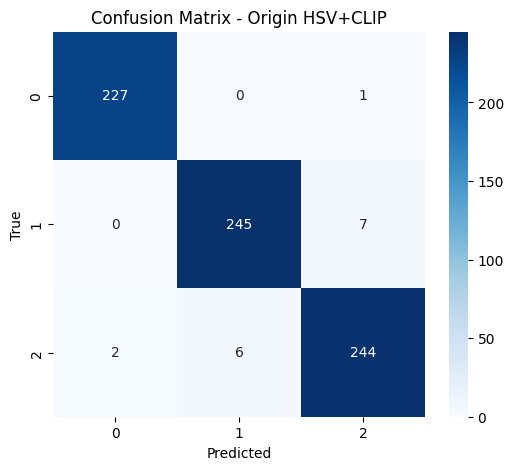


===== Origin HSV+DINO =====
Accuracy : 0.9781
Precision: 0.9788
Recall   : 0.9783
F1-score : 0.9785


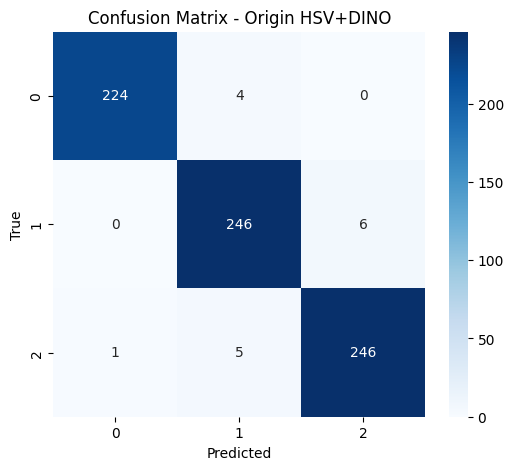


===== Origin HSV+RESNET =====
Accuracy : 0.9563
Precision: 0.9569
Recall   : 0.9571
F1-score : 0.9569


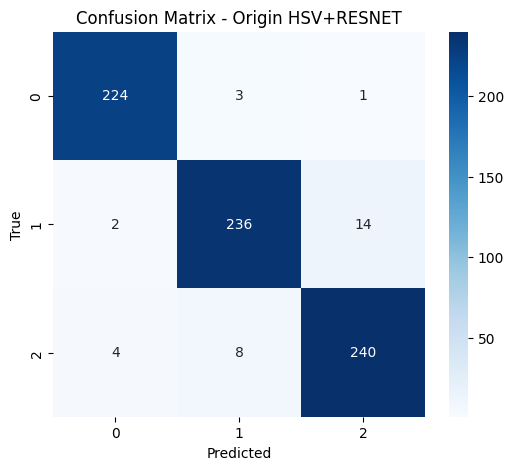

(0.9562841530054644,
 0.9568517003703435,
 0.9571150097465887,
 0.9569344281873136)

In [22]:
# HSV + CLIP
evaluate_model(
    feat_train_origin_hsv_clip, y_train,
    feat_test_origin_hsv_clip, y_test,
    "Origin HSV+CLIP"
)

# HSV + DINO
evaluate_model(
    feat_train_origin_hsv_dino, y_train,
    feat_test_origin_hsv_dino, y_test,
    "Origin HSV+DINO"
)

# HSV + RESNET
evaluate_model(
    feat_train_origin_hsv_resnet, y_train,
    feat_test_origin_hsv_resnet, y_test,
    "Origin HSV+RESNET"
)


===== Encrypted HSV+CLIP =====
Accuracy : 0.7186
Precision: 0.7149
Recall   : 0.7178
F1-score : 0.7139


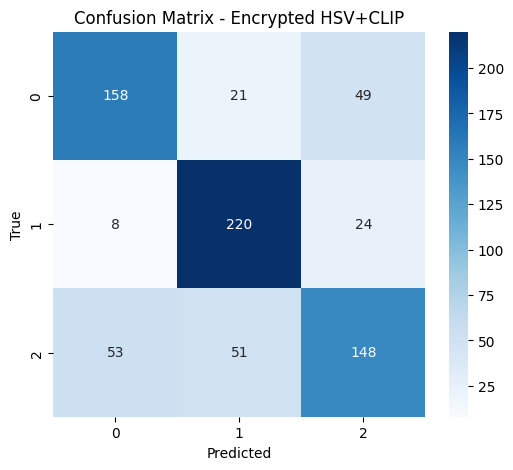


===== Encrypted HSV+DINO =====
Accuracy : 0.7186
Precision: 0.7149
Recall   : 0.7178
F1-score : 0.7139


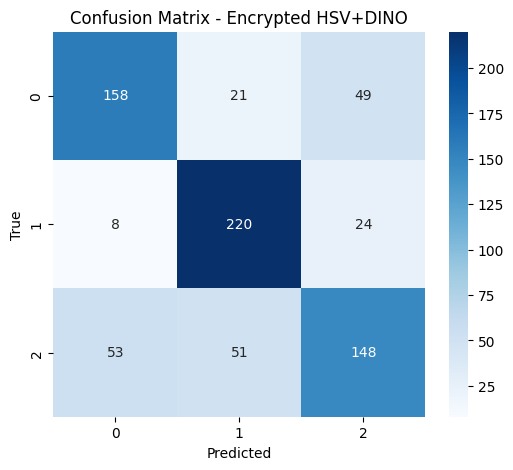


===== Encrypted HSV+RESNET =====
Accuracy : 0.7213
Precision: 0.7176
Recall   : 0.7206
F1-score : 0.7167


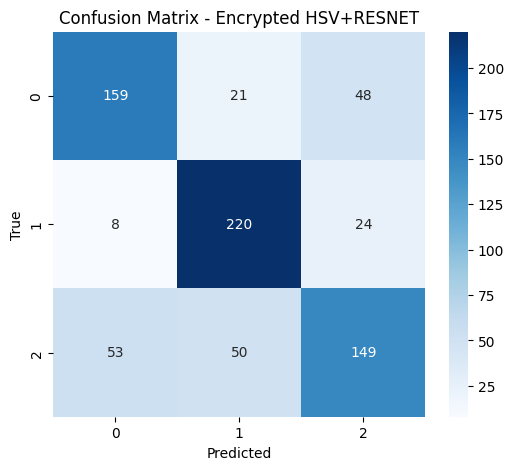

(0.7213114754098361, 0.7176497210760401, 0.7205513784461153, 0.716718548575641)

In [23]:
# HSV + CLIP
evaluate_model(
    feat_train_encrypted_hsv_clip, y_train_enc,
    feat_test_encrypted_hsv_clip, y_test_enc,
    "Encrypted HSV+CLIP"
)

# HSV + DINO
evaluate_model(
    feat_train_encrypted_hsv_dino, y_train_enc,
    feat_test_encrypted_hsv_dino, y_test_enc,
    "Encrypted HSV+DINO"
)

# HSV + RESNET
evaluate_model(
    feat_train_encrypted_hsv_resnet, y_train_enc,
    feat_test_encrypted_hsv_resnet, y_test_enc,
    "Encrypted HSV+RESNET"
)

# HOG + Foundation

In [24]:
#clip
X_train_p = X_train_p_hog.reshape(X_train_p_hog.shape[0], -1)
feat_clip_origin = feat_clip_origin.reshape(feat_clip_origin.shape[0], -1)
X_train_e = X_train_e_hog.reshape(X_train_e_hog.shape[0], -1)
feat_clip_encrypted = feat_clip_encrypted.reshape(feat_clip_encrypted.shape[0], -1)

#dino
X_train_p = X_train_p_hog.reshape(X_train_p_hog.shape[0], -1)
feat_dino_origin = feat_dino_origin.reshape(feat_dino_origin.shape[0], -1)
X_train_e = X_train_e_hog.reshape(X_train_e_hog.shape[0], -1)
feat_dino_encrypted = feat_dino_encrypted.reshape(feat_dino_encrypted.shape[0], -1)

#resnet
X_train_p = X_train_p_hog.reshape(X_train_p_hog.shape[0], -1)
feat_resnet_origin = feat_resnet_origin.reshape(feat_resnet_origin.shape[0], -1)
X_train_e = X_train_e_hog.reshape(X_train_e_hog.shape[0], -1)
feat_resnet_encrypted = feat_resnet_encrypted.reshape(feat_resnet_encrypted.shape[0], -1)

feat_combined_origin_hog_clip = np.concatenate([X_train_p, feat_clip_origin],axis=1)
feat_combined_encrypted_hog_clip = np.concatenate([X_train_e, feat_clip_encrypted],axis=1)

feat_combined_origin_hog_dino = np.concatenate([X_train_p, feat_dino_origin],axis=1)
feat_combined_encrypted_hog_dino = np.concatenate([X_train_e, feat_dino_encrypted],axis=1)

feat_combined_origin_hog_resnet = np.concatenate([X_train_p, feat_resnet_origin],axis=1)
feat_combined_encrypted_hog_resnet = np.concatenate([X_train_e, feat_resnet_encrypted],axis=1)

In [25]:
from sklearn.model_selection import train_test_split

X_train_idx, X_test_idx = train_test_split(
    np.arange(len(feat_combined_origin_hog_clip)),
    test_size=0.2,
    random_state=42,
    stratify=y_train_p_hog
)

# hog+CLIP
# origin
feat_train_origin_hog_clip = feat_combined_origin_hog_clip[X_train_idx]
feat_test_origin_hog_clip  = feat_combined_origin_hog_clip[X_test_idx]

# encrypted
feat_train_encrypted_hog_clip = feat_combined_encrypted_hog_clip[X_train_idx]
feat_test_encrypted_hog_clip  = feat_combined_encrypted_hog_clip[X_test_idx]


# hog+DINO
# origin
feat_train_origin_hog_dino = feat_combined_origin_hog_dino[X_train_idx]
feat_test_origin_hog_dino  = feat_combined_origin_hog_dino[X_test_idx]

# encrypted
feat_train_encrypted_hog_dino = feat_combined_encrypted_hog_dino[X_train_idx]
feat_test_encrypted_hog_dino  = feat_combined_encrypted_hog_dino[X_test_idx]

# hog+resnet
# origin
feat_train_origin_hog_resnet = feat_combined_origin_hog_resnet[X_train_idx]
feat_test_origin_hog_resnet  = feat_combined_origin_hog_resnet[X_test_idx]

# encrypted
feat_train_encrypted_hog_resnet = feat_combined_encrypted_hog_resnet[X_train_idx]
feat_test_encrypted_hog_resnet  = feat_combined_encrypted_hog_resnet[X_test_idx]

y_train = y_train_p_hog[X_train_idx]
y_test  = y_train_p_hog[X_test_idx]

y_train_enc = y_train_p_hog[X_train_idx]
y_test_enc  = y_train_p_hog[X_test_idx]

In [26]:
from sklearn.preprocessing import StandardScaler
#hog + CLIP
scaler_clip = StandardScaler()

feat_train_origin_hog_clip = scaler_clip.fit_transform(feat_train_origin_hog_clip)
feat_test_origin_hog_clip  = scaler_clip.transform(feat_test_origin_hog_clip)

feat_train_encrypted_hog_clip = scaler_clip.transform(feat_train_encrypted_hog_clip)
feat_test_encrypted_hog_clip  = scaler_clip.transform(feat_test_encrypted_hog_clip)

#hog + DINO
scaler_dino = StandardScaler()

feat_train_origin_hog_dino = scaler_dino.fit_transform(feat_train_origin_hog_dino)
feat_test_origin_hog_dino  = scaler_dino.transform(feat_test_origin_hog_dino)

feat_train_encrypted_hog_dino = scaler_dino.transform(feat_train_encrypted_hog_dino)
feat_test_encrypted_hog_dino  = scaler_dino.transform(feat_test_encrypted_hog_dino)

#hog + RESNET
scaler_resnet = StandardScaler()

feat_train_origin_hog_resnet = scaler_resnet.fit_transform(feat_train_origin_hog_resnet)
feat_test_origin_hog_resnet  = scaler_resnet.transform(feat_test_origin_hog_resnet)

feat_train_encrypted_hog_resnet = scaler_resnet.transform(feat_train_encrypted_hog_resnet)
feat_test_encrypted_hog_resnet  = scaler_resnet.transform(feat_test_encrypted_hog_resnet)


===== Origin hog+CLIP =====
Accuracy : 0.9713
Precision: 0.9723
Recall   : 0.9718
F1-score : 0.9720


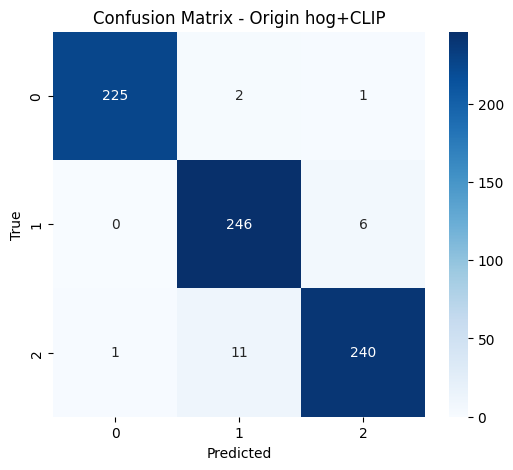


===== Origin hog+DINO =====
Accuracy : 0.9740
Precision: 0.9750
Recall   : 0.9745
F1-score : 0.9746


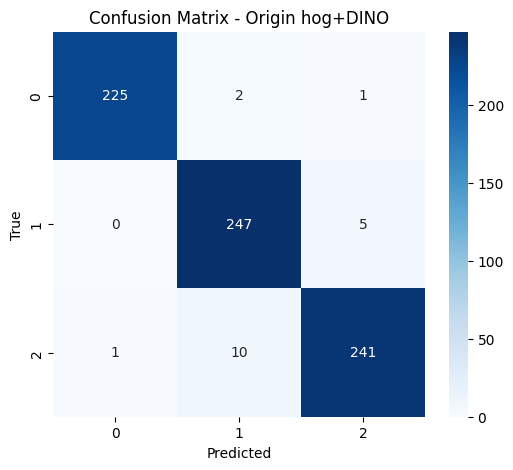


===== Origin hog+RESNET =====
Accuracy : 0.9754
Precision: 0.9762
Recall   : 0.9758
F1-score : 0.9759


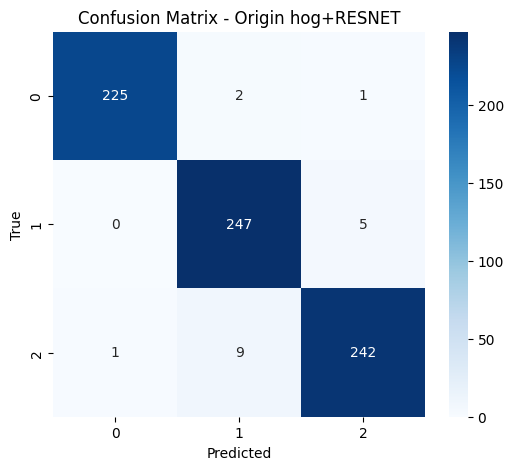

(0.9754098360655737,
 0.9762486713123709,
 0.9757727652464494,
 0.9759389594310558)

In [27]:
# hog + CLIP
evaluate_model(
    feat_train_origin_hog_clip, y_train,
    feat_test_origin_hog_clip, y_test,
    "Origin hog+CLIP"
)

# hog + DINO
evaluate_model(
    feat_train_origin_hog_dino, y_train,
    feat_test_origin_hog_dino, y_test,
    "Origin hog+DINO"
)

# hog + RESNET
evaluate_model(
    feat_train_origin_hog_resnet, y_train,
    feat_test_origin_hog_resnet, y_test,
    "Origin hog+RESNET"
)


===== Encrypted hog+CLIP =====
Accuracy : 0.9467
Precision: 0.9479
Recall   : 0.9473
F1-score : 0.9475


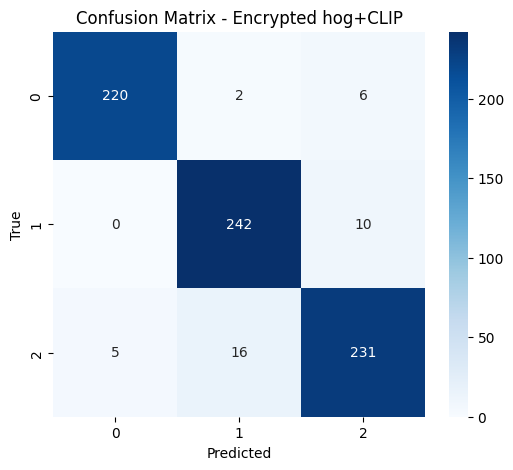


===== Encrypted hog+DINO =====
Accuracy : 0.9495
Precision: 0.9504
Recall   : 0.9497
F1-score : 0.9499


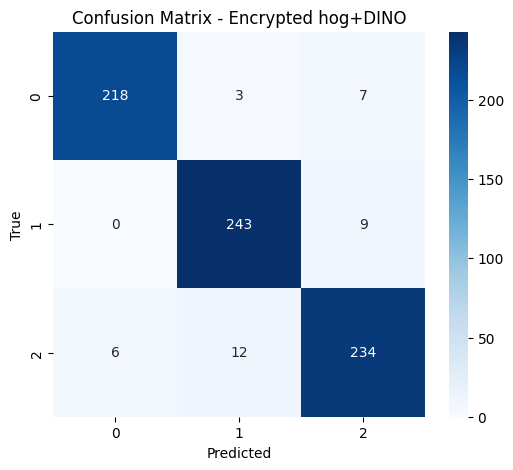


===== Encrypted hog+RESNET =====
Accuracy : 0.9467
Precision: 0.9492
Recall   : 0.9472
F1-score : 0.9479


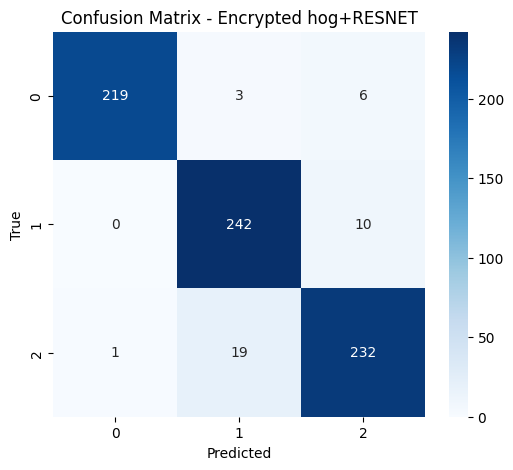

(0.9467213114754098,
 0.9492016943629847,
 0.9471595655806181,
 0.9478876891842009)

In [28]:
# hog + CLIP
evaluate_model(
    feat_train_encrypted_hog_clip, y_train_enc,
    feat_test_encrypted_hog_clip, y_test_enc,
    "Encrypted hog+CLIP"
)

# hog + DINO
evaluate_model(
    feat_train_encrypted_hog_dino, y_train_enc,
    feat_test_encrypted_hog_dino, y_test_enc,
    "Encrypted hog+DINO"
)

# hog + RESNET
evaluate_model(
    feat_train_encrypted_hog_resnet, y_train_enc,
    feat_test_encrypted_hog_resnet, y_test_enc,
    "Encrypted hog+RESNET"
)